In [52]:
import pandas as pd
import pathlib 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
folder_path = pathlib.Path(r"C:\Users\User\Documents\שנה ג\data_science\data-science\govData")
# print files mame in folder
files = folder_path.glob("*.csv")
for file in files:  
    print(file.name)

renamed_ride_data_15.csv
renamed_ride_data_17.csv
renamed_ride_data_19.csv
renamed_ride_data_22.csv
renamed_ride_data_merged.csv
ride_data.csv
ride_data2.csv
ride_data3.csv
ride_data4.csv
ride_data_merged.csv
stations.csv


In [8]:
file_test = folder_path/"renamed_ride_data_15.csv"
df = pd.read_csv(file_test)

print(df.columns)
display(df.head())

Index(['record_id', 'month', 'route_id', 'day_of_week',
       'scheduled_departure_time', 'stop_sequence', 'stop_code',
       'n_observations', 'mean_cumulative_travel_time_min',
       'std_cumulative_travel_time_min', 'mean_cumulative_distance_m',
       'std_cumulative_distance_m', 'route_name'],
      dtype='str')


,record_id,month,route_id,day_of_week,scheduled_departure_time,stop_sequence,stop_code,n_observations,mean_cumulative_travel_time_min,std_cumulative_travel_time_min,mean_cumulative_distance_m,std_cumulative_distance_m,route_name
0,16517238,3,37936,1,15,3,5987,39,3.20,1.01,707,0.057309,15.0
1,16517239,3,37936,1,15,4,5988,39,4.20,1.28,903,0.057309,15.0
2,16517240,3,37936,1,15,5,9921,39,6.74,1.65,1173,0.057309,15.0
3,16517241,3,37936,1,15,6,2540,39,8.29,1.89,1395,0.057309,15.0
4,16517242,3,37936,1,15,7,1255,39,10.07,2.69,1578,0.057309,15.0


In [11]:
# remove rows with nan in route_name
df = df.dropna(subset=['route_name'])

In [13]:
print(df.info())

<class 'pandas.DataFrame'>
Index: 58057 entries, 0 to 58427
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   record_id                        58057 non-null  int64  
 1   month                            58057 non-null  int64  
 2   route_id                         58057 non-null  int64  
 3   day_of_week                      58057 non-null  int64  
 4   scheduled_departure_time         58057 non-null  int64  
 5   stop_sequence                    58057 non-null  int64  
 6   stop_code                        58057 non-null  int64  
 7   n_observations                   58057 non-null  int64  
 8   mean_cumulative_travel_time_min  58057 non-null  float64
 9   std_cumulative_travel_time_min   58057 non-null  float64
 10  mean_cumulative_distance_m       58057 non-null  int64  
 11  std_cumulative_distance_m        58057 non-null  float64
 12  route_name                       5

In [20]:
# find if there are any duplicate rows
duplicates = df[df.duplicated()]
print(f"Number of duplicate rows: {len(duplicates)}")
display(duplicates.head())

# leave only one of the duplicate rows
df = df.drop_duplicates()


Number of duplicate rows: 11412


,record_id,month,route_id,day_of_week,scheduled_departure_time,stop_sequence,stop_code,n_observations,mean_cumulative_travel_time_min,std_cumulative_travel_time_min,mean_cumulative_distance_m,std_cumulative_distance_m,route_name
19998,16517236,3,37936,1,15,1,3300,39,0.62,0.87,0,0.057309,15.0
29999,17458598,3,37936,3,18,4,5988,22,3.96,1.55,914,0.057309,15.0
30000,17458599,3,37936,3,18,5,9921,22,5.67,1.63,1184,0.057309,15.0
30001,17458600,3,37936,3,18,6,2540,22,6.69,1.69,1406,0.057309,15.0
30002,17458601,3,37936,3,18,7,1255,22,7.55,1.81,1589,0.057309,15.0


In [23]:
df_sorted = df.sort_values(['route_id', 'month', 'day_of_week', 'scheduled_departure_time', 'stop_sequence'])
display(df_sorted.head(50))

,record_id,month,route_id,day_of_week,scheduled_departure_time,stop_sequence,stop_code,n_observations,mean_cumulative_travel_time_min,std_cumulative_travel_time_min,mean_cumulative_distance_m,std_cumulative_distance_m,route_name
55634,70236193,1,37936,1,5,1,3300,15,0.80,0.65,0,0.057309,15.0
55635,70236194,1,37936,1,5,2,3301,15,0.92,0.64,291,0.057309,15.0
55636,70236195,1,37936,1,5,3,5987,15,1.81,0.63,707,0.057309,15.0
55637,70236196,1,37936,1,5,4,5988,15,2.06,0.62,914,0.057309,15.0
55638,70236197,1,37936,1,5,5,9921,15,3.01,0.61,1184,0.057309,15.0
55639,70236198,1,37936,1,5,6,2540,15,3.50,0.65,1406,0.057309,15.0
55640,70236199,1,37936,1,5,7,1255,15,3.74,0.66,1589,0.057309,15.0
55641,70236200,1,37936,1,5,8,1028,15,4.90,0.80,1886,0.057309,15.0
55642,70236201,1,37936,1,5,9,1856,15,5.32,0.82,2078,0.057309,15.0
55643,70236202,1,37936,1,5,10,1024,15,6.68,0.88,2364,0.057309,15.0


In [25]:
route_blocks = df_sorted.groupby(['route_id', 'month', 'day_of_week', 'scheduled_departure_time'])

block_size = route_blocks.size().reset_index(name='n_stops')
print(block_size.head())

   route_id  month  day_of_week  scheduled_departure_time  n_stops
0     37936      1            1                         5       16
1     37936      1            1                         6       48
2     37936      1            1                         7       40
3     37936      1            1                         8       20
4     37936      1            1                         9       24


In [ ]:
def get_route_sequnce(group):
    return group.sort_values('stop_sequence')['stop_code'].tolist()

route_sequences = route_blocks.apply(get_route_sequnce).reset_index()
route_sequences = route_sequences.rename(columns={0: 'route_sequence'})

display(route_sequences.head())

,route_id,month,day_of_week,scheduled_departure_time,route_sequence
0,37936,1,1,5,"[3300, 3301, 5987, 5988, 9921, 2540, 1255, 102..."
1,37936,1,1,6,"[3300, 3301, 5987, 5988, 9921, 2540, 1255, 102..."
2,37936,1,1,7,"[9921, 2540, 1255, 1028, 1856, 1024, 1025, 162..."
3,37936,1,1,8,"[6300, 2399, 5979, 2260, 2261, 1053, 6286, 190..."
4,37936,1,1,9,"[6229, 4216, 463, 623, 6300, 2399, 5979, 2260,..."


In [29]:
route_sequences['route_sequence_str'] = route_sequences['route_sequence'].apply(lambda x: '-'.join(map(str, x)))

In [60]:
#count the number of unique route sequences
unique_routes = route_sequences['route_sequence_str'].nunique()
print(f"Number of unique route sequences: {unique_routes}")

# for each route sequence, count the number of occurrences
route_counts = route_sequences['route_sequence_str'].value_counts().reset_index()

print(route_counts.columns)
# add a colmns with the number of stops in the route sequence
route_counts['n_stops'] = route_counts['route_sequence_str'].apply(lambda x: len(x.split('-')))
#display(route_counts.tail(20))

# find the most common and least common route sequences
most_common = route_counts.iloc[0]


most_common_route_str = route_counts.iloc[0]['route_sequence_str']
most_common_route = most_common_route_str.split('-')



Number of unique route sequences: 88
Index(['route_sequence_str', 'count'], dtype='str')


In [ ]:
# 1. הסרת המסלול הנפוץ ביותר כדי להתמקד בחריגים
other_routes = route_counts[route_counts['route_sequence_str'] != most_common_route_str]

# 2. מיון לפי מספר ההופעות (count) כדי לראות מסלולים נדירים
other_routes_sorted = other_routes.sort_values(by='count')

# 3. הצגה של מסלולים נדירים
#display(other_routes_sorted.head(20))  # 20 מסלולים עם הכי מעט הופעות

# 4. נבדוק כמה מסלולים יש עם אותו מספר תחנות
stops_distribution = other_routes_sorted.groupby('n_stops').size().reset_index(name='n_routes')
stops_distribution = stops_distribution.sort_values(by='n_stops')
#display(stops_distribution)

# 5. אפשר גם למיין לפי מספר הופעות יחד עם מספר תחנות
other_routes_sorted = other_routes_sorted.sort_values(by=['n_stops','count'])
#display(other_routes_sorted.head(20))

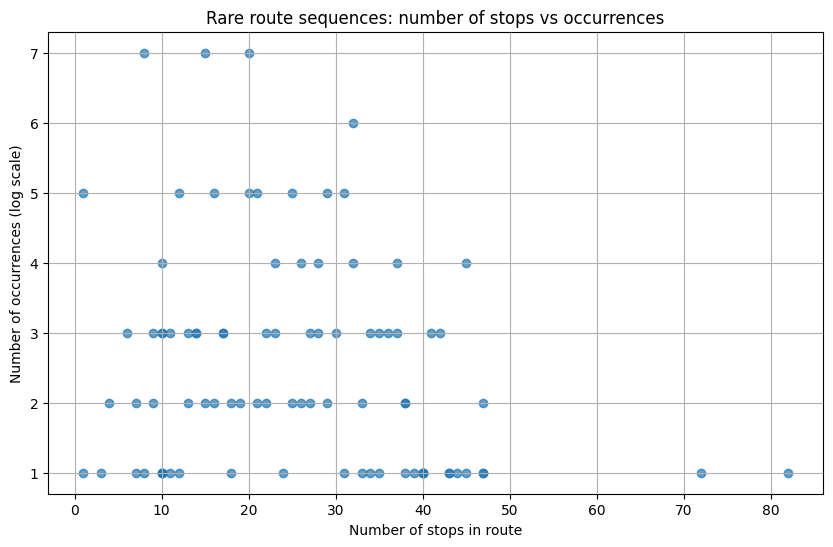

In [63]:
plt.figure(figsize=(10,6))
plt.scatter(other_routes_sorted['n_stops'], other_routes_sorted['count'], alpha=0.7)
#plt.yscale('log')
plt.xlabel('Number of stops in route')
plt.ylabel('Number of occurrences (log scale)')
plt.title('Rare route sequences: number of stops vs occurrences')
plt.grid(True)
plt.show()

In [65]:
# סינון מסלולים לפי מספר תחנות
# הורדת מסלולים עם יותר מ-50 תחנות או פחות מ-10 תחנות
filtered_routes = other_routes_sorted[(other_routes_sorted['n_stops'] <= 50) & (other_routes_sorted['n_stops'] >= 10)]
print(f"Number of routes after filtering: {len(filtered_routes)}")


Number of routes after filtering: 74


In [67]:
stops_file = r"C:\Users\User\Documents\שנה ג\data_science\data-science\govData\jerusalem_stops.csv"
stops_df = pd.read_csv(stops_file)

# create a dictionary that maps stop_code to stop_name
stop_code_to_name = dict(zip(stops_df['stop_code'], stops_df['stop_name']))

def get_stop_names(stop_codes):
    codes = stop_codes.split('-')
    names = [stop_code_to_name.get(int(code), f"Unknown({code})") for code in codes]
    return names


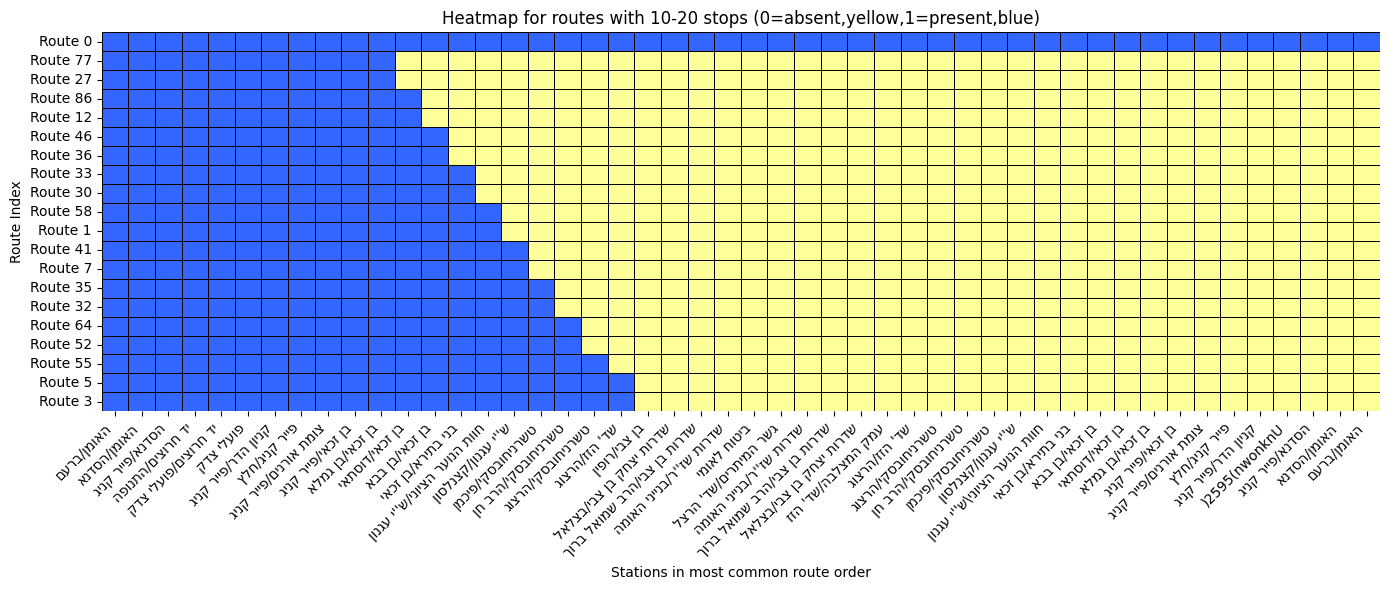

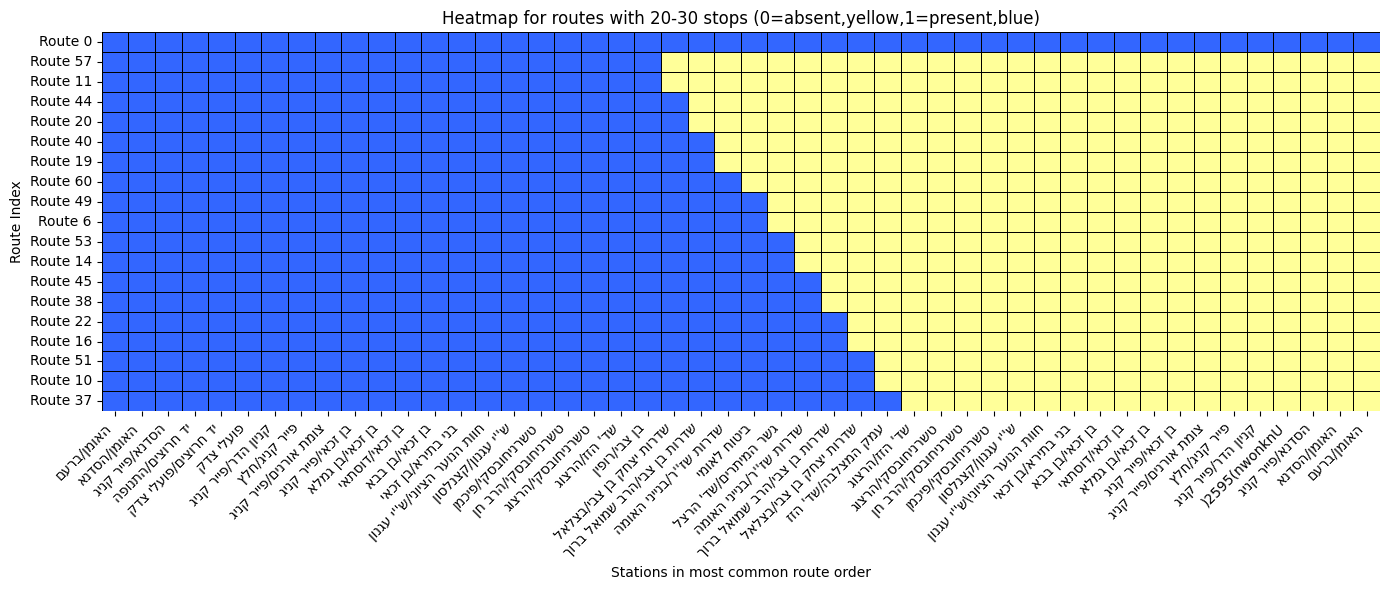

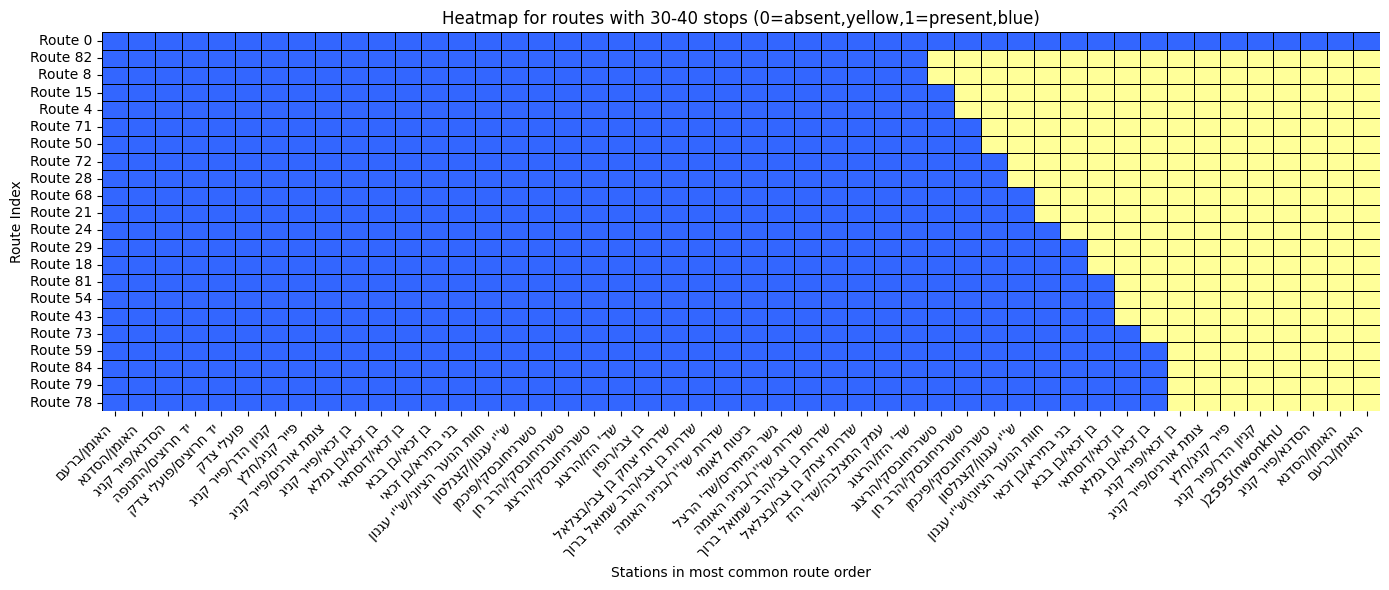

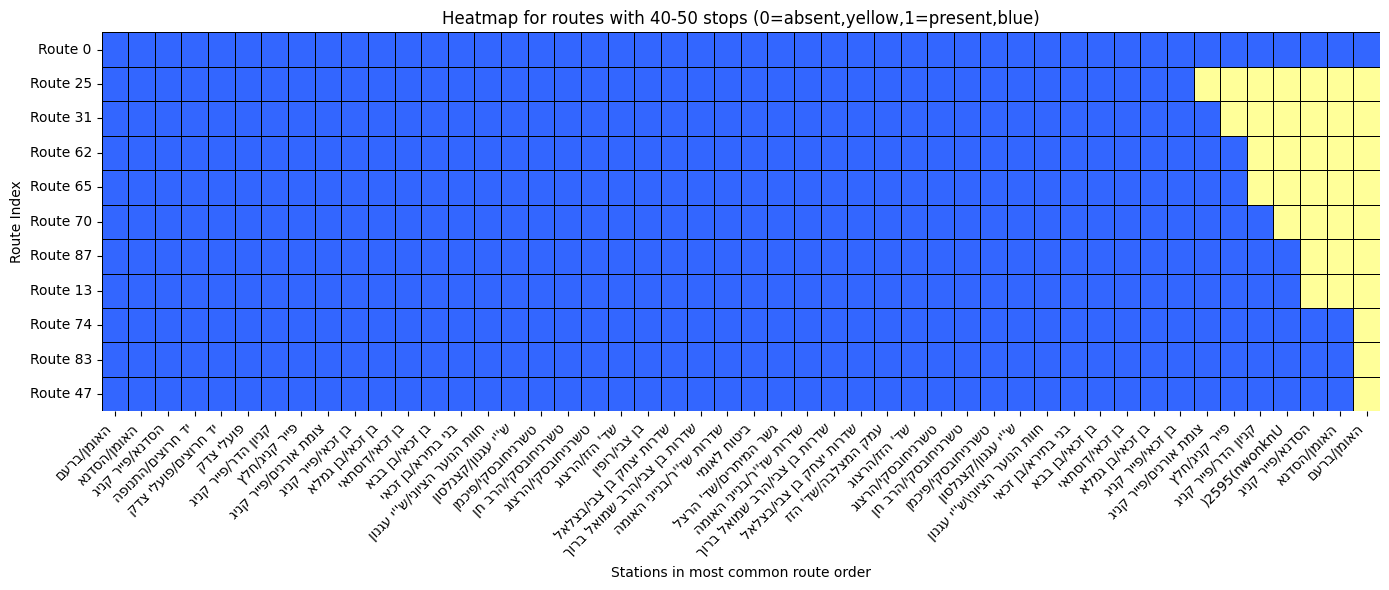

In [76]:
# Bins for number of stops
bins = [10,20,30,40,50]
bin_labels = ["10-20","20-30","30-40","40-50"]

for i in range(len(bins)-1):
    low = bins[i]
    high = bins[i+1]
    subset = filtered_routes[(filtered_routes['n_stops'] > low) & (filtered_routes['n_stops'] <= high)]
    if subset.empty:
        continue

    # כלול את המסלול הנפוץ בראש
    subset_routes = pd.concat([route_counts[route_counts['route_sequence_str']==most_common_route_str], subset])

    heatmap_data = []  # רשימה ריקה
    labels_y = []
    max_len = subset_routes['n_stops'].max()

    for idx, row in subset_routes.iterrows():
        route_names = get_stop_names(row['route_sequence_str'])
        vector = [1]*len(route_names) + [0]*(max_len - len(route_names))
        heatmap_data.append(vector)  # append עכשיו עובד
        labels_y.append(f"Route {idx}")

    heatmap_data = np.array(heatmap_data)

    # תוויות ציר X לפי המסלול הנפוץ
    station_labels = get_stop_names(most_common_route_str)
    station_labels += [""]*(max_len - len(station_labels))
    # station_labels מכיל שמות התחנות בעברית
    station_labels_rtl = [label[::-1] if label != "" else "" for label in station_labels]

    plt.figure(figsize=(14,6))
    sns.heatmap(heatmap_data, annot=False, cbar=False, cmap=cmap,
            xticklabels=station_labels_rtl, yticklabels=labels_y,
            linecolor='black', linewidths=0.5)
    plt.xticks(rotation=45, ha='right')
    plt.title(f"Heatmap for routes with {bin_labels[i]} stops (0=absent,yellow,1=present,blue)")
    plt.ylabel("Route Index")
    plt.xlabel("Stations in most common route order")
    plt.tight_layout()
    plt.show()

